In [997]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Grafiklerin notebook içinde görünmesi için
%matplotlib inline

In [998]:
##dataframe
df = pd.read_csv("data/europe_air_routes.csv")

In [999]:
#EDA(Exploratory Data Analysis)- Veri Keşfi
df.head()
df.info()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 18111 entries, 0 to 18110
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            18111 non-null  int64  
 1   iata_from                     18111 non-null  str    
 2   iata_to                       18111 non-null  str    
 3   price                         18111 non-null  int64  
 4   day1                          18111 non-null  str    
 5   day2                          18111 non-null  str    
 6   day3                          18111 non-null  str    
 7   day4                          18111 non-null  str    
 8   day5                          18111 non-null  str    
 9   day6                          18111 non-null  str    
 10  day7                          18111 non-null  str    
 11  flights_per_day               18111 non-null  str    
 12  common_duration               18111 non-null  int64  
 13  flights_per_

Index(['id', 'iata_from', 'iata_to', 'price', 'day1', 'day2', 'day3', 'day4',
       'day5', 'day6', 'day7', 'flights_per_day', 'common_duration',
       'flights_per_week', 'first_flight', 'last_flight', 'airlineroutes',
       'arrival_airport_country_code', 'arrival_airport_name',
       'arrival_airport_city_name', 'arrival_airport_city_name_en',
       'arrival_airport_country', 'arrival_airport_no_routes',
       'departure_city', 'departure_country', 'departure_ICAO',
       'departure_latitude', 'departure_longitude', 'departure_altitude',
       'arrival_ICAO', 'arrival_latitude', 'arrival_longitude',
       'arrival_altitude'],
      dtype='str')

In [1000]:
#EDA - Veri Keşfi
print(f"Satır Sayısı: {df.shape[0]}")
print(f"Sütun Sayısı: {df.shape[1]}")


Satır Sayısı: 18111
Sütun Sayısı: 33


In [1001]:
#İlk 5 satır
df.head()

,id,iata_from,iata_to,price,day1,day2,day3,day4,day5,day6,...,departure_city,departure_country,departure_ICAO,departure_latitude,departure_longitude,departure_altitude,arrival_ICAO,arrival_latitude,arrival_longitude,arrival_altitude
0,46316,TZL,DTM,70,no,yes,no,yes,no,yes,...,Tulza,Bosnia and Herzegovina,LQTZ,44.458698,18.7248,784,EDLW,51.518299,7.612240,425.0
1,46319,TZL,FMM,30,yes,upcoming,upcoming,yes,yes,upcoming,...,Tulza,Bosnia and Herzegovina,LQTZ,44.458698,18.7248,784,EDJA,47.988800,10.239500,2077.0
2,46322,TZL,MLH,40,no,yes,no,yes,no,yes,...,Tulza,Bosnia and Herzegovina,LQTZ,44.458698,18.7248,784,LFSB,47.590000,7.529167,885.0
3,77197,TZL,BER,40,upcoming,no,upcoming,no,upcoming,no,...,Tulza,Bosnia and Herzegovina,LQTZ,44.458698,18.7248,784,EDDB,52.380001,13.522500,157.0
4,46323,TZL,MMX,90,no,upcoming,no,upcoming,no,upcoming,...,Tulza,Bosnia and Herzegovina,LQTZ,44.458698,18.7248,784,ESMS,55.536305,13.376198,236.0


In [1002]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

arrival_ICAO                    94
arrival_latitude                94
arrival_longitude               94
arrival_altitude                94
arrival_airport_country_code     3
dtype: int64

Veri setindeki eksik değer oranı %1'in altındadır ve sosyal ağın oluşturulmasında kullanılan IATA kodları (iata_from, iata_to) eksiksiz olduğundan analiz sonuçlarını etkilememektedir.

In [1003]:
df.describe()

,id,price,common_duration,flights_per_week,arrival_airport_no_routes,departure_latitude,departure_longitude,departure_altitude,arrival_latitude,arrival_longitude,arrival_altitude
count,18111.000000,18111.000000,18111.000000,18111.000000,18111.000000,18111.000000,18111.000000,18111.000000,18017.000000,18017.000000,18017.000000
mean,40968.389818,131.500193,188.270554,8.935343,102.961846,46.527647,10.626848,422.184584,43.509688,11.135838,477.822889
std,28947.003864,316.923778,132.300212,14.501401,71.253309,7.323643,13.545896,520.332995,11.331455,28.655810,745.766790
min,14.000000,0.000000,20.000000,0.000000,1.000000,27.931900,-25.697901,-15.000000,-34.838402,-149.996002,-72.000000
25%,16213.000000,30.000000,110.000000,2.000000,46.000000,41.138901,0.695556,80.000000,38.282200,-0.461941,65.000000
50%,34771.000000,70.000000,150.000000,4.000000,91.000000,46.927700,9.221960,257.000000,44.413300,10.227200,242.000000
75%,66474.000000,150.000000,220.000000,10.000000,149.000000,51.841301,19.261093,506.000000,51.148102,21.425600,527.000000
max,96475.000000,16100.000000,1120.000000,189.000000,316.000000,69.683296,77.040497,3125.000000,78.246101,177.740997,8361.000000


In [1004]:
airports = set(df["iata_from"]).union(set(df["iata_to"]))

print(f"Toplam Havalimanı Sayısı: {len(airports)}")

Toplam Havalimanı Sayısı: 983


In [1005]:
##Toplam rota sayısı
print("Toplam rota :" , len(df))

Toplam rota : 18111


In [1006]:
##En çok kalkış yapılan havalimanları
top_departure_airports = df["iata_from"].value_counts().head(10)
print("En çok kalkış yapılan havalimanları:")
print(top_departure_airports)

En çok kalkış yapılan havalimanları:
iata_from
IST    316
FRA    285
CDG    277
AMS    267
FCO    235
MUC    229
MAD    226
BCN    224
LHR    217
ZRH    211
Name: count, dtype: int64


In [1007]:
##En çok varış yapılan havalimanları
top_arrival_airports = df["iata_to"].value_counts().head(10)

In [1008]:
##En yoğun şehirler
top_cities_arv = df["arrival_airport_city_name"].value_counts().head(10)
top_cities_dep = df["departure_city"].value_counts().head(10)



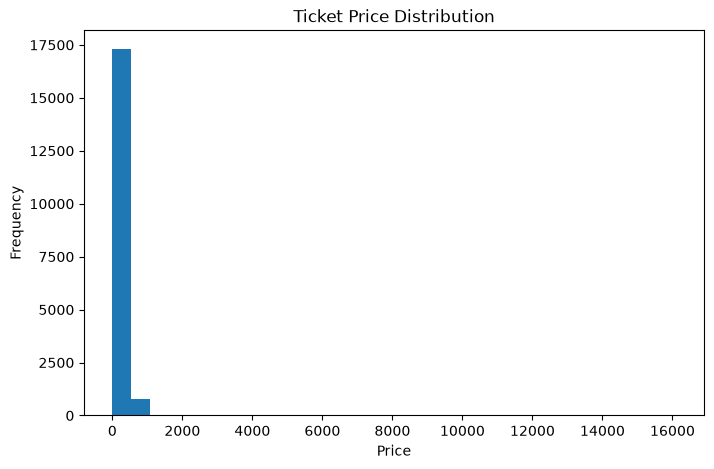

In [1009]:
##Fşyat dağılımı
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=30)
plt.title("Ticket Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

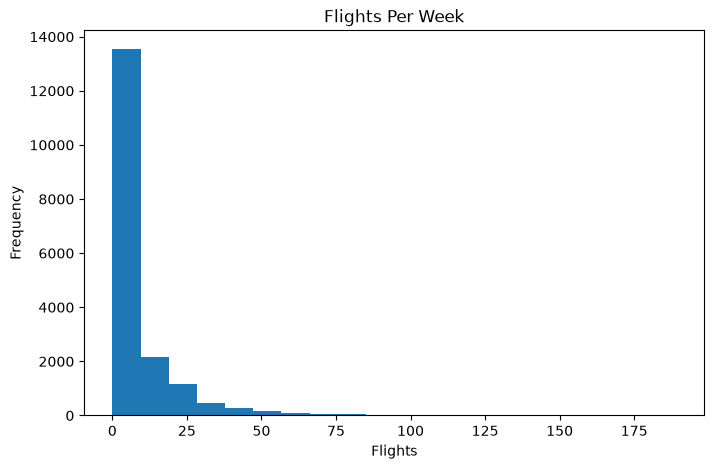

In [1010]:
##Haftalık uçuş dağılımı
plt.figure(figsize=(8,5))
plt.hist(df["flights_per_week"], bins=20)
plt.title("Flights Per Week")
plt.xlabel("Flights")
plt.ylabel("Frequency")
plt.show()

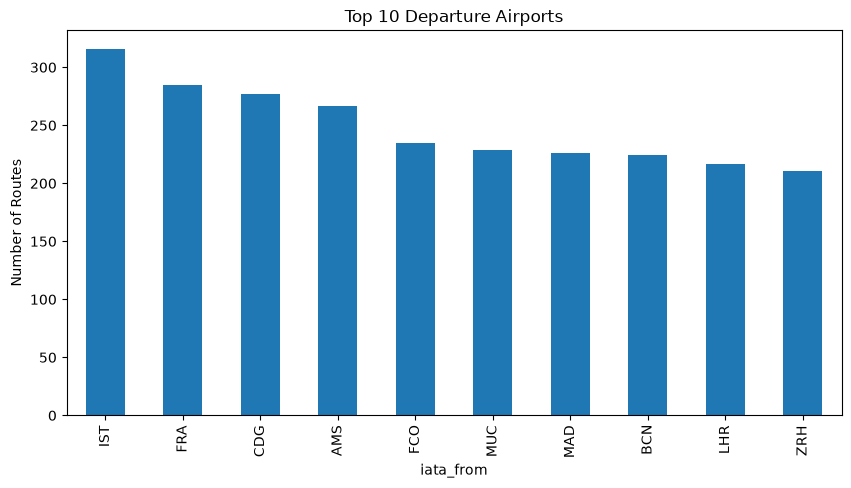

In [1011]:
top10 = df["iata_from"].value_counts().head(10)

plt.figure(figsize=(10,5))

top10.plot(kind="bar")

plt.title("Top 10 Departure Airports")

plt.ylabel("Number of Routes")

plt.savefig("top10_departure_airports.png", dpi=300, bbox_inches="tight")

plt.show()



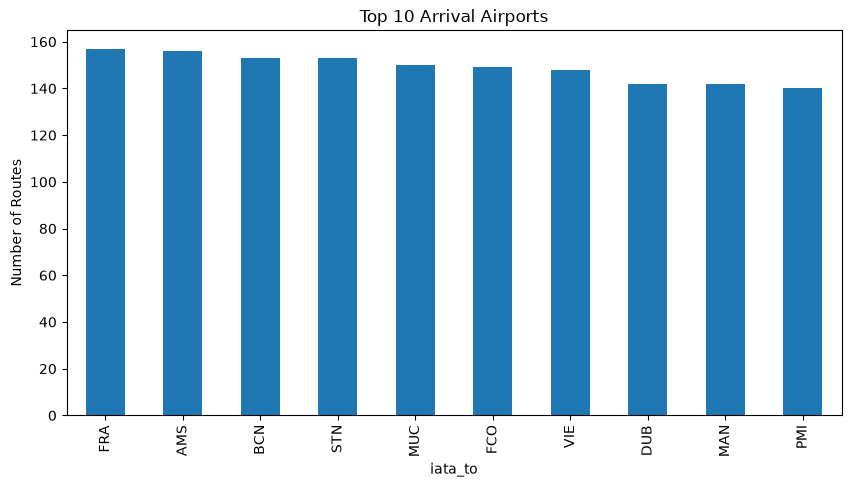

In [1012]:
top10 = df["iata_to"].value_counts().head(10)

plt.figure(figsize=(10,5))

top10.plot(kind="bar")

plt.title("Top 10 Arrival Airports")

plt.ylabel("Number of Routes")

plt.show()

In [1013]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [1014]:
print(df["iata_from"].isnull().sum())
print(df["iata_to"].isnull().sum())

0
0


In [1015]:
df["flights_per_week"].dtype

dtype('int64')

In [1016]:
print((df["price"] < 0).sum())
print((df["common_duration"] <= 0).sum())

0
0


The dataset was checked for duplicate records, missing values, incorrect data types, and invalid numerical values. No duplicate records or missing IATA airport codes were found. Missing values existed only in a few geographic attributes, which were not required for network construction. Therefore, no records were removed during the cleaning process.

Explotary Data Analysis part (EDA) is over.

--------------------------------------------------------

NETWORK CONSTRUCTION


In [1017]:
##NETWORK CONSTRUCTION

G = nx.from_pandas_edgelist(
    df,
    source="iata_from",
    target="iata_to",
    edge_attr=[
        "price",
        "flights_per_week",
        "common_duration"
    ],
    create_using=nx.DiGraph()
)

In [1018]:
##Undirected version - just in case we want to analyze the network as undirected
G_undirected = G.to_undirected()

In [1019]:
##Attributes of the graph
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Network density:", nx.density(G))
print("Is strongly connected:", nx.is_strongly_connected(G))
print("Is weakly connected:", nx.is_weakly_connected(G))



Number of nodes: 983
Number of edges: 18111
Network density: 0.01876192627001179
Is strongly connected: False
Is weakly connected: True


In [1020]:
##Ortalama Degree
avg_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()

print(avg_degree)

36.84842319430315


Graph construction complete. Vertex and edge numbers calculated. Network density calculated. Strong and weak connectivity checked.


-------------------------------

SOCIAL NETWORK ANALYSIS


Degree Centrality


In [1021]:
##Use undirected graph for degree centrality
degree_centrality = nx.degree_centrality(G_undirected)

##Convert to DataFrame for easier analysis
degree_df = pd.DataFrame(
    degree_centrality.items(),
    columns=["Airport", "Degree_Centrality"]
)

##Sort
degree_df = degree_df.sort_values(
    by="Degree_Centrality", ascending=False
)





In [1022]:
###Top 10 airports by degree centrality
top10_degree = degree_df.head(10)
print(top10_degree)

   Airport  Degree_Centrality
25     IST           0.321792
19     FRA           0.291242
22     CDG           0.283096
20     AMS           0.274949
59     FCO           0.240326
18     MUC           0.233198
94     MAD           0.230143
43     BCN           0.228106
24     LHR           0.220978
15     ZRH           0.215886


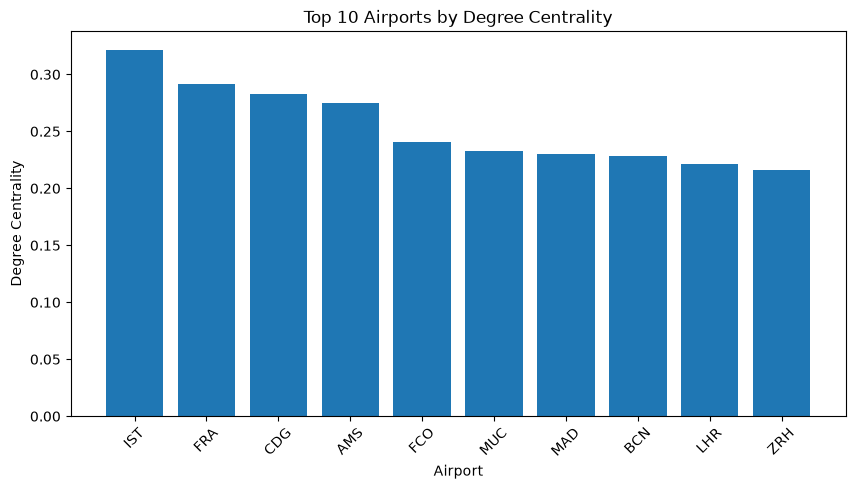

In [1023]:
##Visualize
top10 = degree_df.head(10)

plt.figure(figsize=(10,5))

plt.bar(top10["Airport"], top10["Degree_Centrality"])

plt.title("Top 10 Airports by Degree Centrality")

plt.xlabel("Airport")

plt.ylabel("Degree Centrality")

plt.xticks(rotation=45)

plt.show()

Airports with the highest degree centrality have the largest number of direct connections within the European airport transportation network.

In [1024]:
airport_info = (
    df[["iata_to", "arrival_airport_name", "arrival_airport_city_name"]]
    .drop_duplicates(subset="iata_to")
)

degree_df = degree_df.merge(
    airport_info,
    left_on="Airport",
    right_on="iata_to",
    how="left"
)

degree_df = degree_df[[
    "Airport",
    "arrival_airport_name",
    "arrival_airport_city_name",
    "Degree_Centrality"
]]

degree_df.head(10)

,Airport,arrival_airport_name,arrival_airport_city_name,Degree_Centrality
0,IST,Istanbul Airport,Istanbul,0.321792
1,FRA,Frankfurt Airport,Frankfurt,0.291242
2,CDG,Charles De Gaulle,Paris,0.283096
3,AMS,Schiphol,Amsterdam,0.274949
4,FCO,Fiumicino,Rome,0.240326
5,MUC,Munich Airport,Munich,0.233198
6,MAD,Barajas,Madrid,0.230143
7,BCN,El Prat Airport,Barcelona,0.228106
8,LHR,Heathrow,London,0.220978
9,ZRH,Zurich Airport,Zurich,0.215886


In-degree and out-degree

In [1025]:
##IN-DEGREE OUT-DEGREE
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())

In [1026]:
##Create df
in_degree_df = pd.DataFrame(
    in_degree.items(),
    columns=["Airport", "In_Degree"]
).sort_values(
    by="In_Degree", ascending=False
)

out_degree_df = pd.DataFrame(
    out_degree.items(),
    columns=["Airport", "Out_Degree"]
).sort_values(
    by="Out_Degree", ascending=False
)

In [1027]:
##top10
print("Top 10 In-Degree Airports")
display(in_degree_df.head(10))

print("Top 10 Out-Degree Airports")
display(out_degree_df.head(10))

Top 10 In-Degree Airports


,Airport,In_Degree
19,FRA,157
20,AMS,156
43,BCN,153
93,STN,153
18,MUC,150
59,FCO,149
11,VIE,148
125,MAN,142
104,DUB,142
23,PMI,140


Top 10 Out-Degree Airports


,Airport,Out_Degree
25,IST,316
19,FRA,285
22,CDG,277
20,AMS,267
59,FCO,235
18,MUC,229
94,MAD,226
43,BCN,224
24,LHR,217
15,ZRH,211


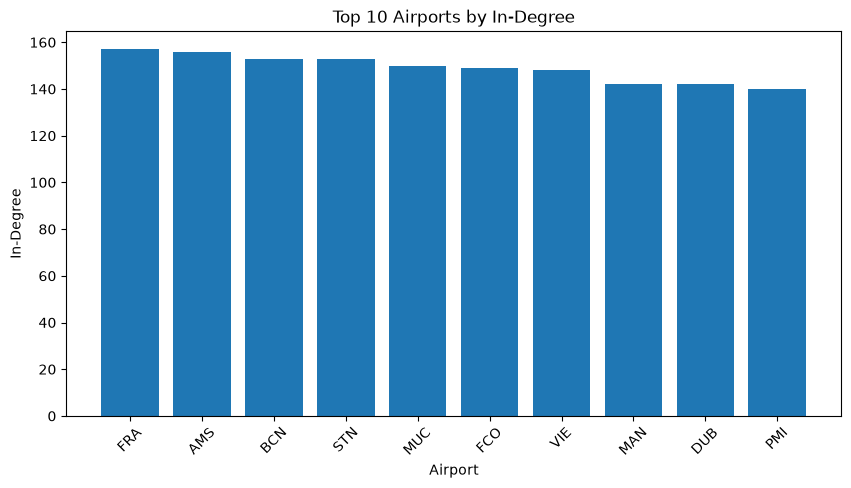

In [1028]:
##In-Degree Visualization
top10 = in_degree_df.head(10)

plt.figure(figsize=(10,5))

plt.bar(top10["Airport"], top10["In_Degree"])

plt.title("Top 10 Airports by In-Degree")

plt.xlabel("Airport")

plt.ylabel("In-Degree")

plt.xticks(rotation=45)

plt.show()

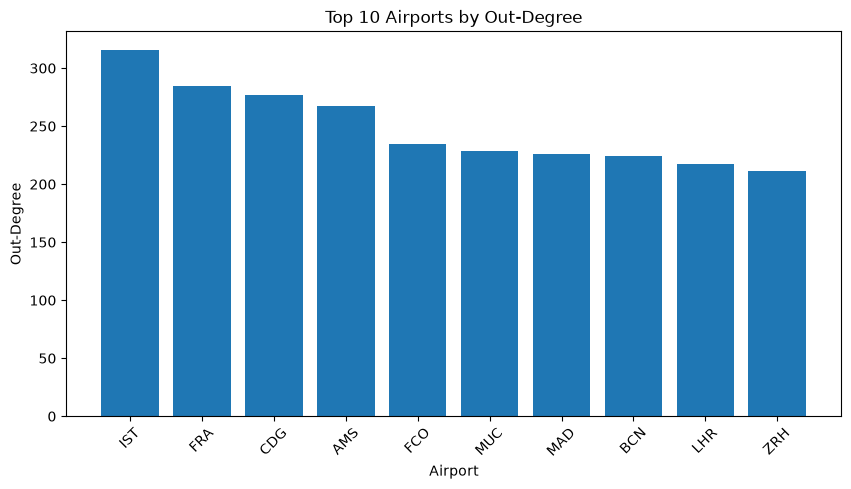

In [1029]:
#Out-Degree Visualization
top10 = out_degree_df.head(10)

plt.figure(figsize=(10,5))

plt.bar(top10["Airport"], top10["Out_Degree"])

plt.title("Top 10 Airports by Out-Degree")

plt.xlabel("Airport")

plt.ylabel("Out-Degree")

plt.xticks(rotation=45)

plt.show()

In [1030]:
airport_info = (
    df[["iata_to",
        "arrival_airport_name",
        "arrival_airport_city_name"]]
    .drop_duplicates("iata_to")
)

Betweenness Centrality nedir?

Degree Centrality kaç bağlantın var? diye soruyordu.

Betweenness ise farklı bir soru soruyor:

"En kısa yolların üzerinde en sık hangi havaalanı bulunuyor?"

Yani:

Bir havaalanının kendisi çok fazla bağlantıya sahip olmayabilir ama herkes oradan geçiyorsa yine de çok kritiktir.

Bu metrik aktarma (hub) havaalanlarını ortaya çıkarır.

In [1031]:
betweenness = nx.betweenness_centrality(
    G,
    normalized=True
)

In [1032]:
betweenness_df = pd.DataFrame(
    betweenness.items(),
    columns=["Airport", "Betweenness_Centrality"]
)

In [1033]:
##sort
betweenness_df = betweenness_df.sort_values(
    by="Betweenness_Centrality", ascending=False
)

In [1034]:
##top10
betweenness_df.head(10)

,Airport,Betweenness_Centrality
25,IST,0.027520
17,AYT,0.012939
19,FRA,0.011696
22,CDG,0.010234
20,AMS,0.010173
94,MAD,0.008601
93,STN,0.007390
436,SVO,0.007269
24,LHR,0.007173
35,ARN,0.006967


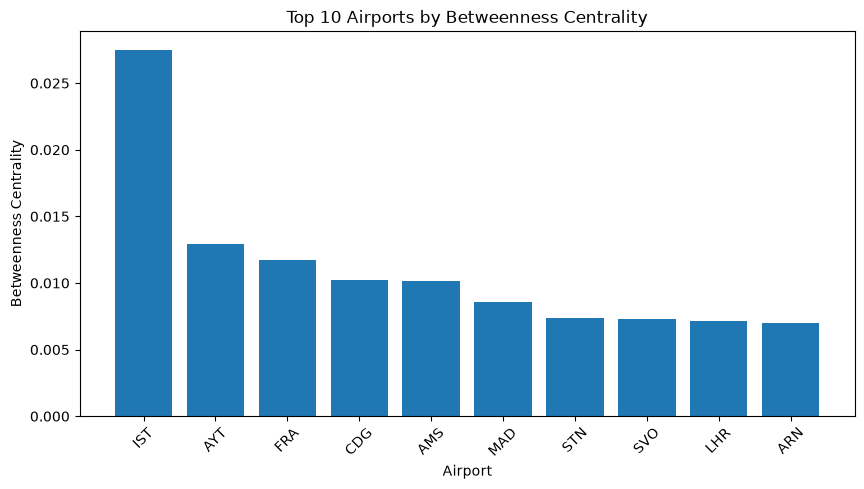

In [1035]:
top10 = betweenness_df.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10["Airport"],
    top10["Betweenness_Centrality"]
)

plt.title("Top 10 Airports by Betweenness Centrality")

plt.xlabel("Airport")

plt.ylabel("Betweenness Centrality")

plt.xticks(rotation=45)

plt.show()

Unlike Degree Centrality, Betweenness Centrality highlights airports that act as strategic transfer hubs rather than simply having many direct connections. Istanbul Airport (IST) ranks first in both metrics, confirming its dominant role within the network. Interestingly, Antalya (AYT), Stockholm Arlanda (ARN), and Moscow Sheremetyevo (SVO) achieve relatively high betweenness values despite not ranking among the airports with the highest degree centrality. This indicates that these airports serve as important bridges connecting different regions of the network.

In [1036]:
comparison = degree_df.merge(
    betweenness_df,
    on="Airport"
)

comparison.head(10)

,Airport,arrival_airport_name,arrival_airport_city_name,Degree_Centrality,Betweenness_Centrality
0,IST,Istanbul Airport,Istanbul,0.321792,0.027520
1,FRA,Frankfurt Airport,Frankfurt,0.291242,0.011696
2,CDG,Charles De Gaulle,Paris,0.283096,0.010234
3,AMS,Schiphol,Amsterdam,0.274949,0.010173
4,FCO,Fiumicino,Rome,0.240326,0.005881
5,MUC,Munich Airport,Munich,0.233198,0.006036
6,MAD,Barajas,Madrid,0.230143,0.008601
7,BCN,El Prat Airport,Barcelona,0.228106,0.005755
8,LHR,Heathrow,London,0.220978,0.007173
9,ZRH,Zurich Airport,Zurich,0.215886,0.003978


This table illustrates the difference between degree centrality and betweennes centrality